In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [39]:
df = pd.read_csv('Tweets.csv')
print("Shape:",df.shape)
df.head()

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [40]:
#check sentiment distribution
print(df['airline_sentiment'].value_counts())

#check for missing values
print("\Missing values:")
print(df.isnull().sum())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
\Missing values:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\DELL\AppData\Local\Temp\ipykernel_9568\1795844056.py:5: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing values:")


In [41]:
#keep only relevant columns
df = df[['airline_sentiment','negativereason','airline','text', 'tweet_created']]

#drop rows where text is missing
df = df.dropna(subset=['text'])

print("Clean_shape:",df.shape)
df.head()

Clean_shape: (14640, 5)


,airline_sentiment,negativereason,airline,text,tweet_created
0,neutral,NaN,Virgin America,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800
1,positive,NaN,Virgin America,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800
2,neutral,NaN,Virgin America,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800
3,negative,Bad Flight,Virgin America,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800
4,negative,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800


In [42]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtag symbol
    text = re.sub(r'#', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

print("Before cleaning:")
print(df['text'][3])
print("\nAfter cleaning:")
print(df['cleaned_text'][3])

Before cleaning:
@VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse

After cleaning:
really aggressive blast obnoxious entertainment guest face amp little recourse


In [43]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['cleaned_text'].apply(get_vader_sentiment)

# Compare VADER vs original labels
print("VADER Results:")
print(df['vader_sentiment'].value_counts())
print("\nOriginal Labels:")
print(df['airline_sentiment'].value_counts())

# Accuracy check
match = (df['vader_sentiment'] == df['airline_sentiment']).sum()
accuracy = round(match / len(df) * 100, 2)
print(f"\nVADER Accuracy vs Original Labels: {accuracy}%")

VADER Results:
vader_sentiment
positive    6457
negative    4518
neutral     3665
Name: count, dtype: int64

Original Labels:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

VADER Accuracy vs Original Labels: 50.66%


In [ ]:
# Prepare data
X = df['cleaned_text']
y = df['airline_sentiment']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Vectorize
tfidf = TfidfVectorizer(max_features=5000)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

# Train
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_tf, y_train)

# Accuracy
preds = model.predict(X_test_tf)
acc = accuracy_score(y_test, preds)
print(f"Logistic Regression Accuracy: {round(acc*100, 2)}%")

Logistic Regression Accuracy: 76.57%


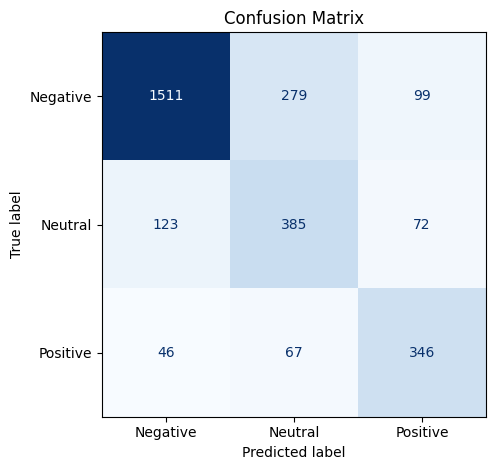

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    preds,
    display_labels=['Negative', 'Neutral', 'Positive'],
    colorbar=False,
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

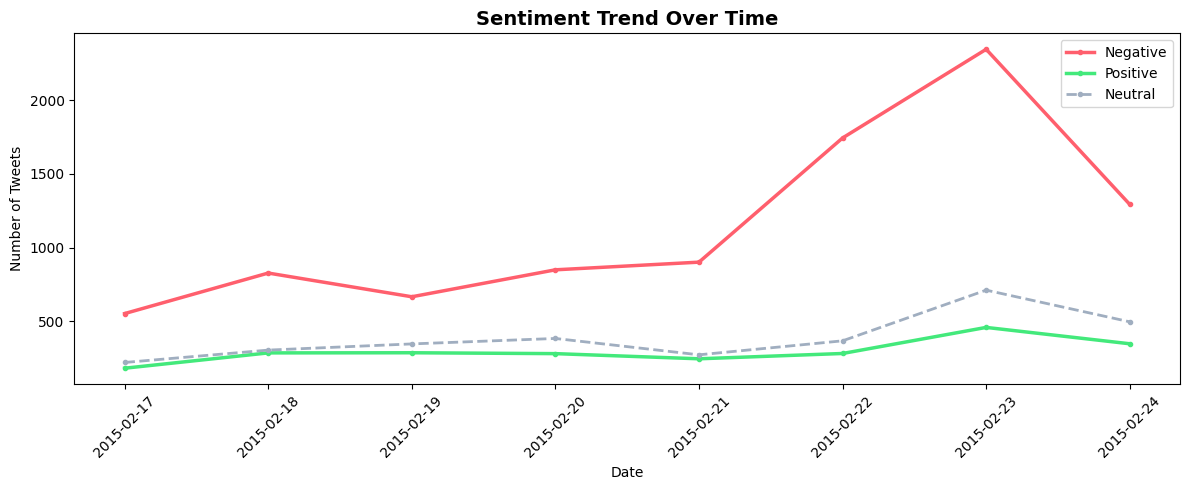

In [46]:
# Convert date column
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
df['date'] = df['tweet_created'].dt.date

# Count sentiments per day
time_df = df.groupby(['date','airline_sentiment']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12,5))
if 'negative' in time_df.columns:
    plt.plot(time_df.index, time_df['negative'],
             color='#ff5f6d', linewidth=2.5, label='Negative', marker='o', markersize=3)
if 'positive' in time_df.columns:
    plt.plot(time_df.index, time_df['positive'],
             color='#43e97b', linewidth=2.5, label='Positive', marker='o', markersize=3)
if 'neutral' in time_df.columns:
    plt.plot(time_df.index, time_df['neutral'],
             color='#a0aec0', linewidth=2, label='Neutral',
             linestyle='--', marker='o', markersize=3)

plt.title('Sentiment Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

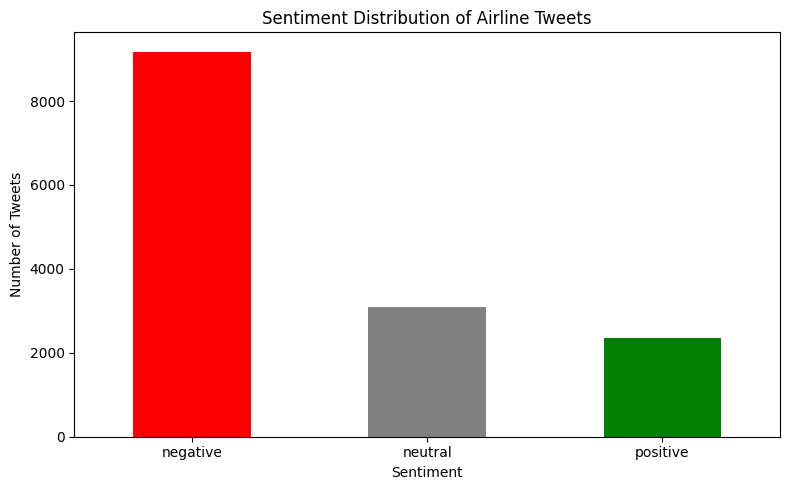

<Figure size 640x480 with 0 Axes>

In [47]:
# Sentiment distribution bar chart
df['airline_sentiment'].value_counts().plot(
    kind='bar',
    color=['red', 'gray', 'green'],
    figsize=(8,5)
)

plt.title('Sentiment Distribution of Airline Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')

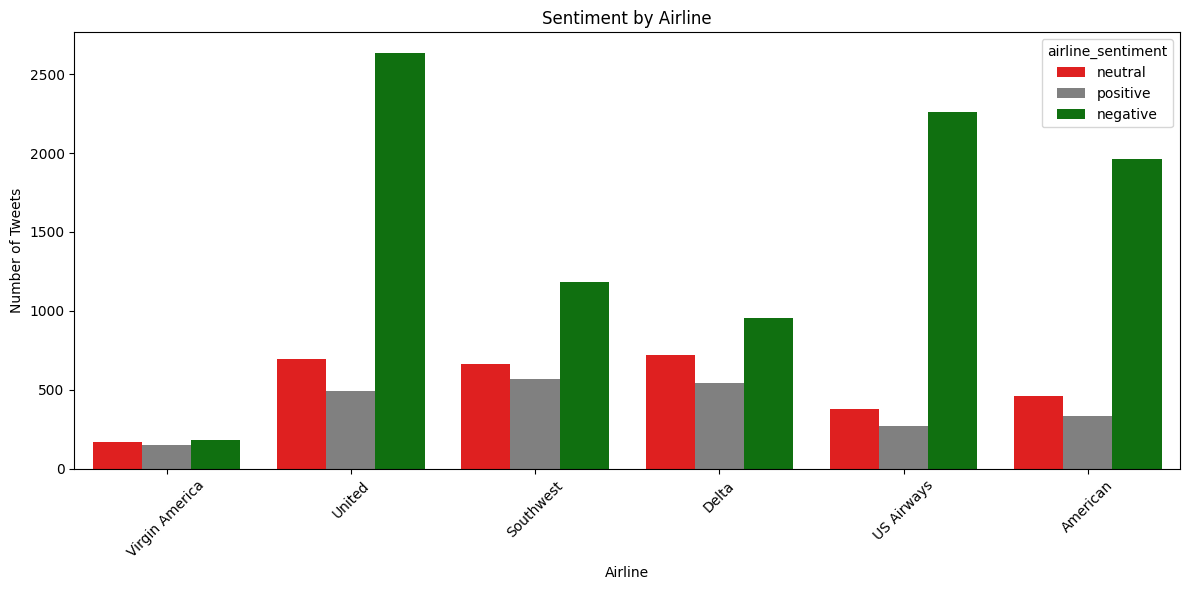

<Figure size 640x480 with 0 Axes>

In [48]:
# Sentiment by each airline
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='airline', hue='airline_sentiment',
              palette=['red','gray','green'])

plt.title('Sentiment by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')

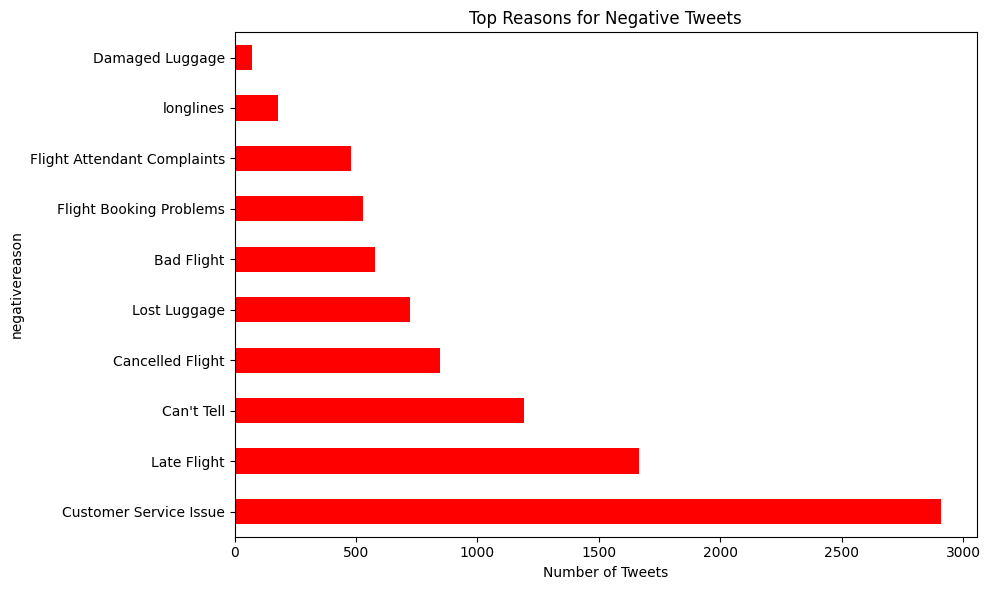

<Figure size 640x480 with 0 Axes>

In [49]:
# Why are people complaining?
plt.figure(figsize=(10,6))
df['negativereason'].value_counts().dropna().plot(
    kind='barh',
    color='red'
)

plt.title('Top Reasons for Negative Tweets')
plt.xlabel('Number of Tweets')
plt.tight_layout()
plt.show()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')

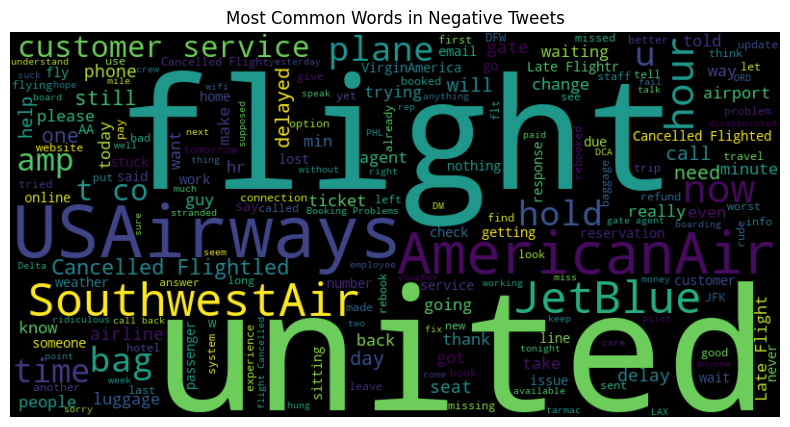

<Figure size 640x480 with 0 Axes>

In [50]:
from wordcloud import WordCloud

negative_tweets = ' '.join(df[df['airline_sentiment']=='negative']['text'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_tweets)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets')
plt.show()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')

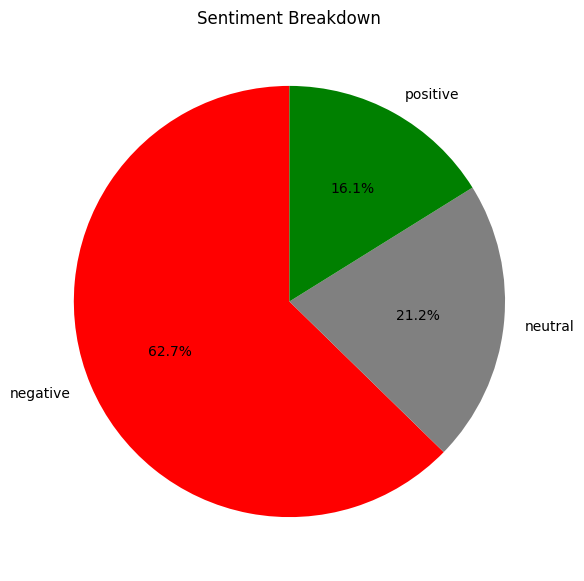

<Figure size 640x480 with 0 Axes>

In [51]:
plt.figure(figsize=(7,7))
df['airline_sentiment'].value_counts().plot(
    kind='pie',
    colors=['red','gray','green'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Sentiment Breakdown')
plt.ylabel('')
plt.show()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')